In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('smartphoneusage.csv')

print(f"Datasetul are {df.shape[0]} randuri.")
df.head()

Datasetul are 7500 randuri.


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [2]:
print("Valori lipsa pe fiecare coloana:")
print(df.isnull().sum())

print(f"\nNumar de randuri duplicate: {df.duplicated().sum()}")

Valori lipsa pe fiecare coloana:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Numar de randuri duplicate: 0


In [3]:
#completarea valorilor lipsa
df['addiction_level'] = df['addiction_level'].fillna('None')

# sterg dupliate
df = df.drop_duplicates()

print("gata curatarea")

gata curatarea


C:\Users\Laura\AppData\Local\Temp\ipykernel_218176\2246057094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='addiction_level', y='social_media_hours', data=df, order=ordine, palette='Reds')


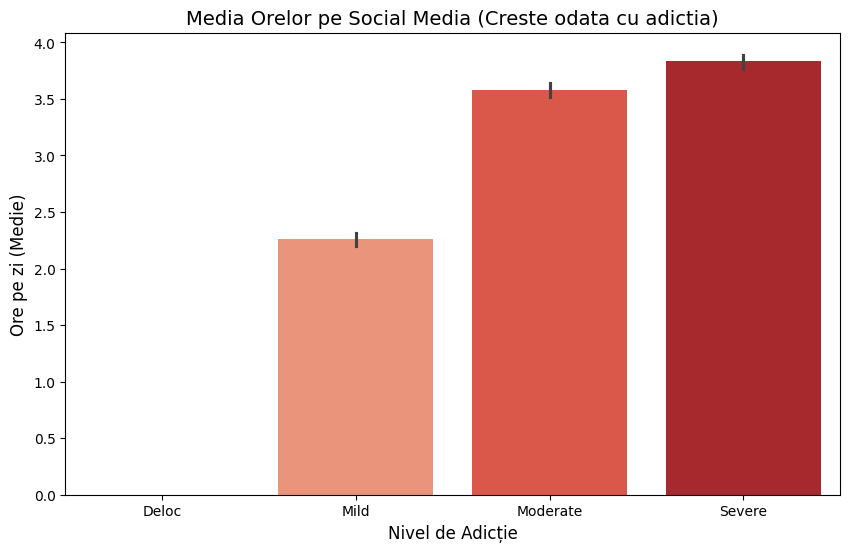

In [4]:
plt.figure(figsize=(10, 6))
# Ordonam categoriile ca sa aiba sens logic
ordine = ['Deloc', 'Mild', 'Moderate', 'Severe']

sns.barplot(x='addiction_level', y='social_media_hours', data=df, order=ordine, palette='Reds')

plt.title('Media Orelor pe Social Media (Creste odata cu adictia)', fontsize=14)
plt.xlabel('Nivel de Adicție', fontsize=12)
plt.ylabel('Ore pe zi (Medie)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('smartphoneusage.csv')

df['addiction_level'] = df['addiction_level'].fillna('Deloc')

--- Corelația cu variabila țintă (Addicted Label) ---
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day     -0.000660
dtype: float64

--- Information Gain (Importanța coloanelor) ---
daily_screen_time_hours    0.243956
weekend_screen_time        0.219215
social_media_hours         0.166518
work_study_hours           0.011784
sleep_hours                0.008733
age                        0.005151
gaming_hours               0.000000
notifications_per_day      0.000000
app_opens_per_day          0.000000
dtype: float64

--- Gini Index (Feature Importance) ---
social_media_hours         0.500661
daily_screen_time_hours    0.498570
weekend_screen_time        0.000769
age                        0.000000
gaming_hours               0.0000

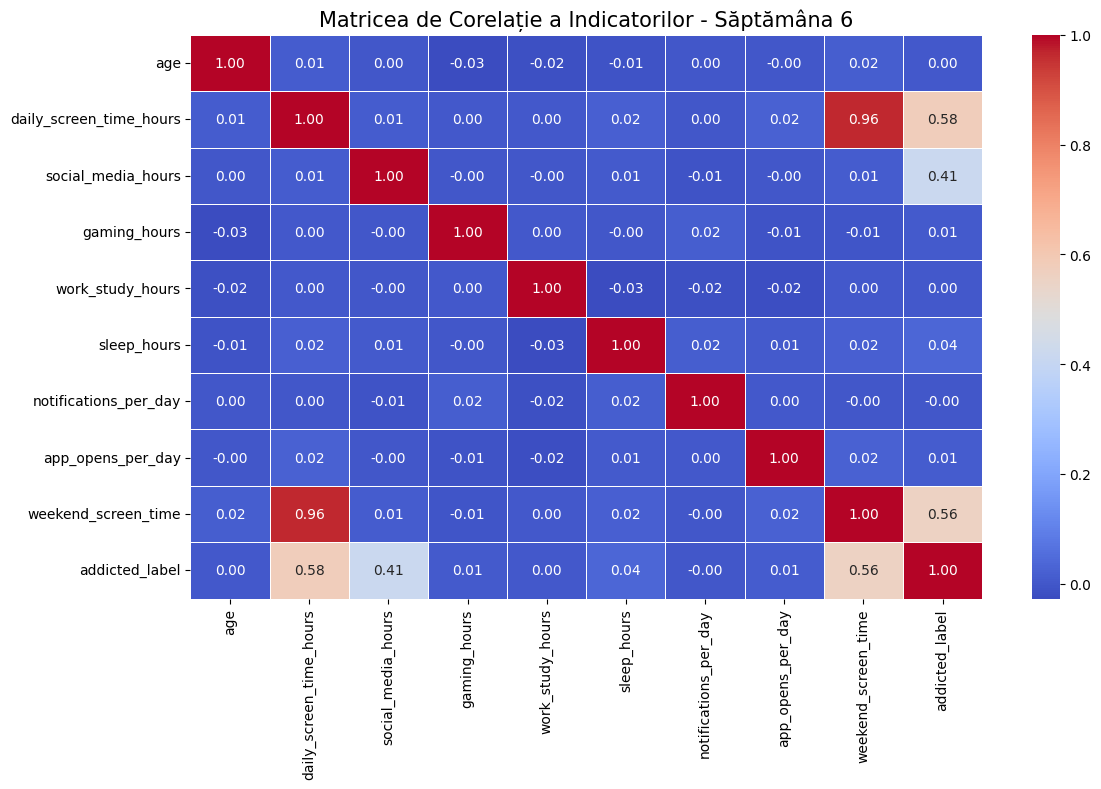

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pregatirea datelor pentru analiza
X = df.drop(columns=['addicted_label', 'user_id'], errors='ignore').select_dtypes(include=['number'])
y = df['addicted_label']

# 2.Corelatia Pearson
correlations = X.corrwith(y).sort_values(ascending=False)
print("Addicted Label")
print(correlations)

# 3. Indicator
importances = mutual_info_classif(X, y)
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\nImportanta coloanelor")
print(feature_importances)

# 4.Gini Index
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)
gini_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n Gini Index")
print(gini_importance)

# 5.Matricea de Corelatie
plt.figure(figsize=(12, 8))

df_corr = X.copy()
df_corr['addicted_label'] = y

#calculam matricea
corr_matrix = df_corr.corr()

# Heatmap-ul
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matricea de Corelatie a Indicatorilor', fontsize=15)
plt.tight_layout()
plt.show()